In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import itertools
import seaborn_image as isns
import statsmodels.api as sm
import statsmodels.formula.api as smf
sns.set(font_scale=2) 
sns.set_style("ticks")

In [139]:
df = pd.read_csv('ephys_analysis_MC.csv')
gal = df[df.Gal_positive == 'yes']
ephys = df[df.Gal_positive !='yes']
sample_num= ephys[ephys.Gal_positive== 'no'].shape[0]/4
ephys = pd.concat([ephys, gal.sample(int(sample_num))], axis = 0)
ephys.loc[ephys.Gal_positive !='Unknown','state'] = 'Pre'
ephys.loc[ephys.Gal_positive =='Unknown','state'] = 'Post'
ephys.rename(columns = {'Instant_freq_(Hz)_1/ISI':'Instant_freq_(Hz)'}, inplace =True)

0.9352589600282745


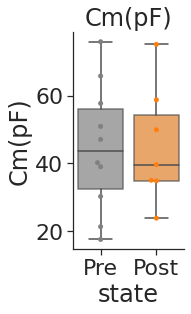

0.25657610210782655


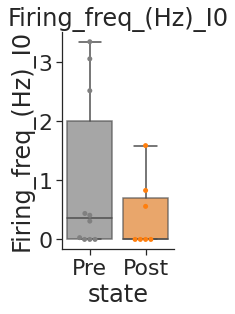

0.2974247331896916


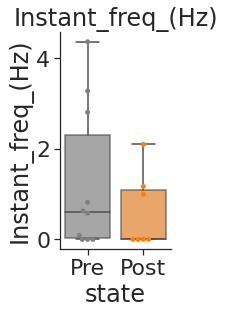

0.28474376566061704


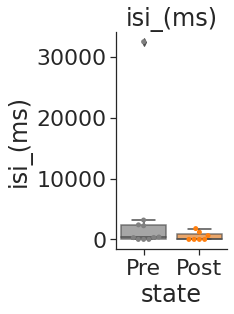

0.355917683749582


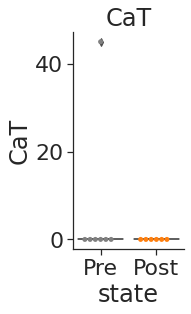

0.026114047267306765


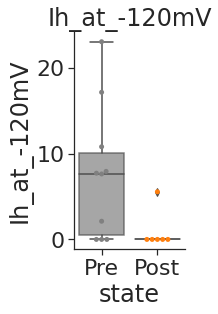

0.41740279267197156


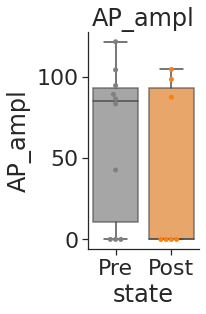

0.22576189401183278


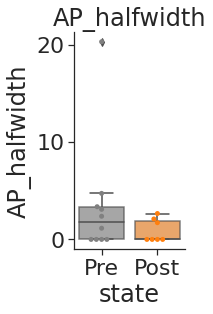

0.22581949210312693


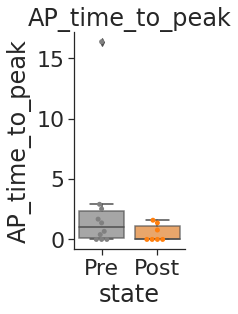

0.20258931282993156


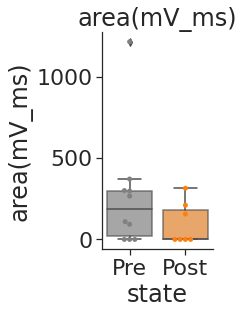

0.5245132748851229


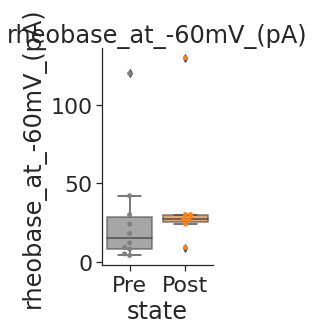

0.29395659416715836


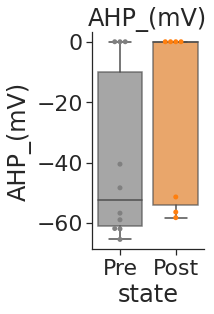

0.9770800425401727


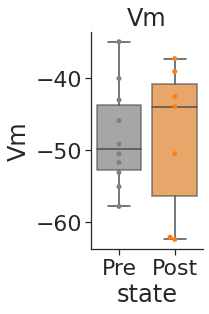

0.16574139808975594


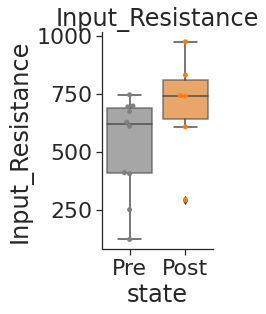

0.4800639824840557


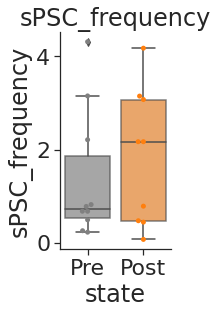

0.7754890857421115


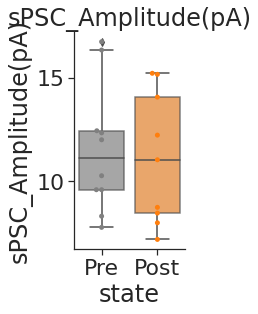

0.42565769553201804


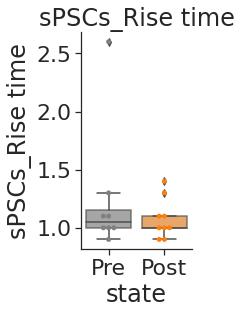

0.22477033496367194


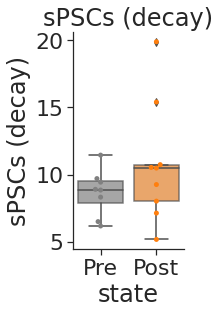

nan


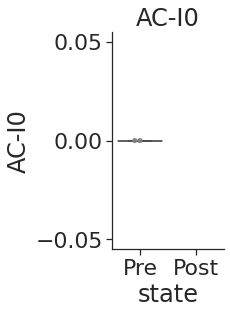

nan


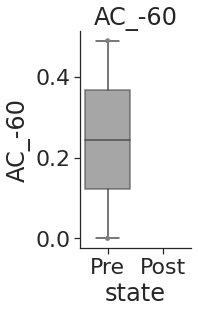

In [141]:
ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)', 'AC-I0', 'AC_-60']

for column in ls:
    _, p = stats.ttest_ind(ephys[ephys.state == 'Pre'][column].dropna(),
                                ephys[ephys.state == 'Post'][column].dropna(),
                                equal_var = False)
    print(p)
    
    ephys[column] = pd.to_numeric(ephys[column])
    fig,ax = plt.subplots(figsize = (2,4))
    sns.swarmplot(x='state', y =column, data= ephys, palette = ['gray', 'Tab:orange'])
    sns.boxplot(x='state', y =column, data= ephys, palette = ['gray', 'Tab:orange'], boxprops=dict(alpha=0.7))
    sns.despine()
    plt.title(column)
    plt.savefig(f'output_figures/{column}.png',dpi = 300, bbox_inches = 'tight')
    plt.show()

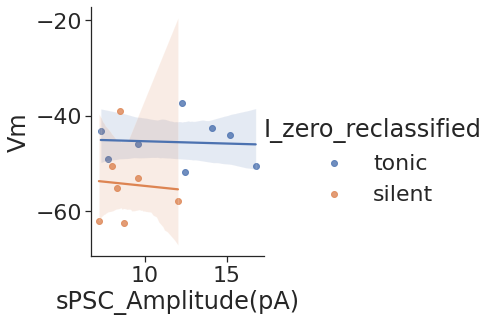

In [123]:
sns.lmplot(x = 'sPSC_Amplitude(pA)',
            y = 'Vm',
           hue = 'I_zero_reclassified',
            data = ephys)
sns.despine()

In [124]:
ephys_prop = pd.crosstab(ephys['state'], ephys['I_zero_reclassified'], margins = True).reset_index()
ephys_prop = ephys_prop.set_index('state')
ephys_prop = ephys_prop.iloc[:-1, :-1]
stat, p, dof, expected  = stats.chi2_contingency(ephys_prop)
print(p)


0.536268306257384


In [125]:
ephys_prop = ephys_prop.apply(lambda x: x.div(x.sum()).mul(100), axis=1)
cols = ['silent', 'tonic']
ephys_prop = ephys_prop[cols]
ephys_prop = ephys_prop.reset_index()
ephys_prop['state'] = pd.Categorical(ephys_prop['state'], ['Pre', 'Post'])

ephys_prop = ephys_prop.sort_values(by = ['state'])

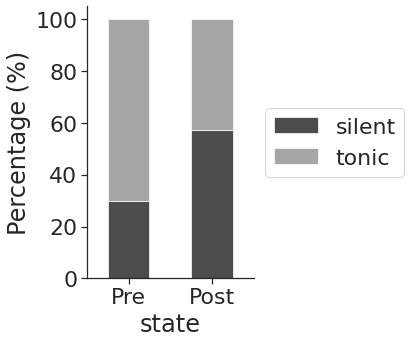

In [143]:
ephys_prop.plot(
          x = 'state', 
          kind = 'bar', 
          stacked = True,  
          mark_right = False,
          color = ['black', 'gray'],
          figsize = (3,5), alpha = 0.7)
plt.xticks(rotation = 0)
ax = plt.gca()
plt.ylabel('Percentage (%)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.savefig('output_figures/silent_prop.png',dpi = 300, bbox_inches = 'tight')